
# **Maestría en Inteligencia Artificial Aplicada**

[![Institution](https://img.shields.io/badge/Instituto-Tecnológico%20de%20Monterrey-1F497D?style=for-the-badge&logo=graduation-cap)](https://tec.mx)
[![Course](https://img.shields.io/badge/Curso-Navegación%20autónoma-FF6B6B?style=for-the-badge&logo=eye)](https://tec.mx)![Activity](https://img.shields.io/badge/Actividad-Proyecto%20Final-F9AB00?style=for-the-badge&logo=googlecolab)


</center>

### **Profesores**
- **Profesor Titular:** Dr. David Antonio Torres
- **Profesor Asistente:** Mtra. Yetnalezi Quintas Ruiz
---

## **Equipo 01**

<div style="display: flex; justify-content: center; margin: 20px 0;">
  <table style="border-collapse: collapse; font-family: Arial, sans-serif;">
    <thead>
      <tr style="border-bottom: 2px solid #333;">
        <th style="padding: 10px 40px; text-align: center;">Nombre</th>
        <th style="padding: 10px 40px; text-align: center;">Matrícula</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Luis Gabriel Lobato Barajas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797069</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Ángel Eduardo Pérez Cruz</td>
        <td style="padding: 8px 40px; text-align: center;">A01797661</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Juan Carlos Pérez Nava</td>
        <td style="padding: 8px 40px; text-align: center;">A01795941</td>
      </tr>
      <tr>
        <td style="padding: 8px 40px; text-align: center;">Israel Sánchez Arenas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797385</td>
      </tr>
    </tbody>
  </table>
</div>

## **<font color="#895cf9">Detalles de la Actividad</font>**
- **Título:** Proyecto Final
- **Fecha de entrega:** Junio 30 2026
- **Modalidad:** Equipo

## **<font color="orange">Objetivo del Proyecto</font>**

Al completar este proyecto final, habrás aplicado la mayoría de los conceptos relacionados con Aprendizaje Máquina y Redes Neuronales Profundas y la programación de vehículos autónomos.

---

## **<font color="red">📚 **Tabla de Contenidos**</font>**

1.  **Librerias utilizadas**
2.  **Carga del Dataset**
3.  **Distribución del Ángulo de Dirección**
4.  **Balanceo del Dataset**
5.  **Distribución: Entrenamiento vs Validación**
6.  **Augmentación de Imágenes**
7.  **Arquitectura de la Red (NVIDIA CNN)**
8.  **Curva de Pérdida del Entrenamiento**
9.  **Referencias**

## **<font color="#895cf9">Modelo NVIDIA — Clonación de Comportamiento (Steering)</font>**

Esta libreta entrena una red neuronal convolucional basada en la arquitectura
**NVIDIA end-to-end** ([Bojarski et al., 2016](https://arxiv.org/abs/1604.07316))
para predecir el **ángulo de dirección** de un vehículo a partir de la imagen
de su cámara frontal. Los datos se generan en el simulador **Webots**
(`dataset/labels.csv` + `dataset/images/`).

## **<font color="orange">Librerías utilizadas</font>**

Las dependencias de la primera celda se agrupan por su función dentro del *pipeline*:

| Grupo | Librería | Uso en la libreta |
|---|---|---|
| **Biblioteca estándar** | `os`, `math`, `random` | Rutas de archivos, cálculos auxiliares y muestreo aleatorio |
| **Cómputo y datos** | `numpy`, `pandas` | Arreglos numéricos y lectura/manipulación de `labels.csv` |
| **Visualización** | `matplotlib` | Histogramas de distribución y muestreo de imágenes |
| **Visión / Augmentación** | `cv2` (OpenCV), `imgaug` | Carga de imágenes y aumentos (zoom, pan, brillo, flip) |
| **Machine Learning** | `scikit-learn` | Mezcla (`shuffle`) y división train/validación |
| **Deep Learning** | `keras` (backend `torch`), `torch` | Definición, compilación y entrenamiento del modelo |

> **Nota sobre NumPy 2.0:** `np.sctypes` fue eliminado en NumPy 2.0, pero
> `imgaug` todavía depende de él. Por eso lo restauramos manualmente justo
> después de importar NumPy y **antes** de importar `imgaug`.

In [ ]:
# --- Biblioteca estandar ---
import os
import math
import random

# --- Computo numerico y datos ---
import numpy as np
import pandas as pd

if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, bytes, str, np.void]
    }

# --- Visualizacion ---
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Vision por computadora y augmentacion ---
import cv2
from imgaug import augmenters as iaa

# --- Machine learning (scikit-learn) ---
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# --- Deep learning (Keras sobre PyTorch) ---
import torch
import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Input, Conv2D, Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

def load_image(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

In [ ]:
OUTPUT_DIR = 'dataset'

In [ ]:
if torch.cuda.is_available():
    print(f"GPU detectada : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ADVERTENCIA: No se detectó GPU — el entrenamiento será muy lento en CPU.")

print(f"Backend Keras : {keras.backend.backend()}")
print(f"PyTorch       : {torch.__version__}")

GPU detectada : NVIDIA GeForce RTX 5080
VRAM          : 17.1 GB
Backend Keras : torch
PyTorch       : 2.12.0+cu130


## **<font color="orange">Carga del Dataset</font>**

Leemos `labels.csv` en un `DataFrame` de pandas. Cada fila corresponde a un
*frame* grabado por el controlador de Webots, junto con las órdenes de control
en ese instante. Las columnas son:

| Columna | Descripción |
|---|---|
| `timestamp` | Identificador único del *frame* (también es el nombre base de la imagen) |
| `sim_time` | Tiempo de simulación, en segundos |
| `image` | Nombre del archivo `.png` asociado al *frame* |
| `steering` | **Ángulo de dirección** — la etiqueta que el modelo aprenderá a predecir |
| `speed` | Velocidad del vehículo en ese instante |
| `command` | Orden de navegación (p. ej. recto / giro), usada por el controlador |

Con `fullDataset.head()` inspeccionamos las primeras filas para verificar que
los datos se cargaron correctamente antes de continuar con el preprocesamiento.

In [ ]:
csv_path = os.path.join(OUTPUT_DIR, 'labels.csv')
images_dir = os.path.join(OUTPUT_DIR, 'images')

if os.path.exists(csv_path):
    n_imgs = len(os.listdir(images_dir)) if os.path.isdir(images_dir) else 0
    print(f"Dataset encontrado: '{csv_path}'")
    print(f"  {n_imgs} imagenes en '{images_dir}/'")
else:
    raise FileNotFoundError(
        f"No se encontro '{csv_path}'. Graba primero el dataset con el "
        f"controlador de Webots (tecla 'g')."
    )

Dataset encontrado: 'dataset/labels.csv'
  10671 imagenes en 'dataset/images/'


In [ ]:
fullDataset = pd.read_csv(csv_path)

print(f"{len(fullDataset):,} registros cargados desde '{csv_path}'")
print(f"Columnas: {list(fullDataset.columns)}")
fullDataset.head()

10,671 registros cargados desde 'dataset/labels.csv'
Columnas: ['timestamp', 'sim_time', 'image', 'steering', 'speed', 'command']


,timestamp,sim_time,image,steering,speed,command
0,JC_20260621_135651_133376,2.784,JC_20260621_135651_133376.png,-0.00515,50,2
1,JC_20260621_135651_342319,2.992,JC_20260621_135651_342319.png,0.00475,50,2
2,JC_20260621_135651_549496,3.200,JC_20260621_135651_549496.png,0.00856,50,2
3,JC_20260621_135651_757322,3.408,JC_20260621_135651_757322.png,-0.00545,50,2
4,JC_20260621_135651_965474,3.616,JC_20260621_135651_965474.png,-0.02175,50,2


In [ ]:
fullDataset['image_path'] = fullDataset['image'].apply(
    lambda f: os.path.join(images_dir, f)
)

print("Ruta de ejemplo:")
print(" ", fullDataset['image_path'].iloc[0])

n_ok = sum(os.path.exists(p) for p in fullDataset['image_path'])
print(f"\nVerificacion: {n_ok:,} / {len(fullDataset):,} imagenes encontradas.")

Ruta de ejemplo:
  dataset/images/JC_20260621_135651_133376.png

Verificacion: 10,671 / 10,671 imagenes encontradas.


In [ ]:
data = fullDataset[['image_path', 'steering']].copy()

print(f"Columnas : {list(data.columns)}")
print(f"Registros: {len(data):,}")
data.head()

Columnas : ['image_path', 'steering']
Registros: 10,671


,image_path,steering
0,dataset/images/JC_20260621_135651_133376.png,-0.00515
1,dataset/images/JC_20260621_135651_342319.png,0.00475
2,dataset/images/JC_20260621_135651_549496.png,0.00856
3,dataset/images/JC_20260621_135651_757322.png,-0.00545
4,dataset/images/JC_20260621_135651_965474.png,-0.02175


## **<font color="orange">Distribución del Ángulo de Dirección</font>**

Antes de entrenar conviene observar **cómo se reparten los valores de
`steering`** en el dataset. Para ello agrupamos los ángulos en `num_bins = 25`
intervalos (*bins*) y contamos cuántas muestras cae en cada uno.

La línea horizontal marca el límite `samples_per_bin = 400`: los *bins* que lo
superan (en rojo) están **sobre-representados**. Como el vehículo circula la
mayor parte del tiempo casi recto, es de esperar que el ángulo `0.0` domine la
distribución.

Este desbalance es importante porque, sin corregirlo, el modelo aprendería a
**ir siempre recto** y fallaría en las curvas. El histograma justifica el paso
de **balanceo** que aplicamos a continuación.

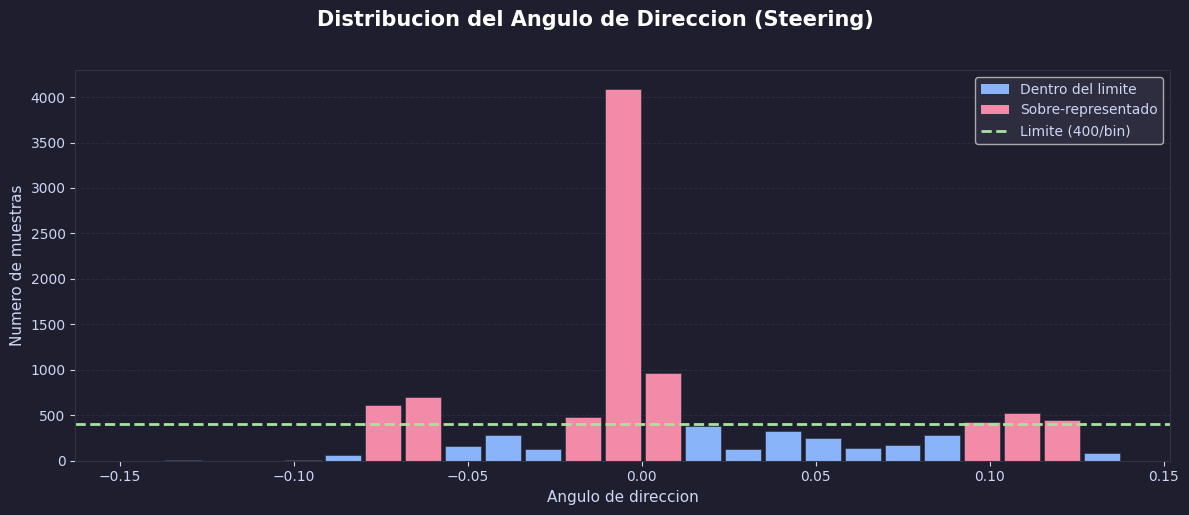

In [ ]:
num_bins = 25
samples_per_bin = 400

hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
width = bins[1] - bins[0]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Distribucion del Angulo de Direccion (Steering)', color='white',
             fontsize=15, fontweight='bold', y=1.02)

ax.set_facecolor('#1e1e2e')
colors = ['#f38ba8' if h > samples_per_bin else '#89b4fa' for h in hist]
ax.bar(center, hist, width=width * 0.9, color=colors, edgecolor='#313244', linewidth=0.5)
ax.axhline(samples_per_bin, color='#a6e3a1', linewidth=2, linestyle='--')
ax.set_xlabel('Angulo de direccion', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Numero de muestras', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

leyenda = [
    Patch(facecolor='#89b4fa', label='Dentro del limite'),
    Patch(facecolor='#f38ba8', label='Sobre-representado'),
    plt.Line2D([0], [0], color='#a6e3a1', linewidth=2, linestyle='--',
               label=f'Limite ({samples_per_bin}/bin)'),
]
ax.legend(handles=leyenda, facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

## **<font color="orange">Balanceo del Dataset</font>**

El histograma anterior confirma que algunos ángulos —sobre todo los cercanos a
`0.0` (ir recto)— están **sobre-representados**. Si entrenáramos con esta
distribución, el modelo minimizaría el error simplemente prediciendo casi
siempre "recto", y fallaría en las curvas, que es justo donde más importa.

**Solución — Submuestreo (*undersampling*):**
Recorremos los `num_bins` intervalos y, en cada uno que supere
`samples_per_bin = 400`, descartamos los registros sobrantes. El paso clave es
mezclar (`shuffle`) los índices del *bin* **antes** de recortar: así los que
conservamos son una muestra aleatoria y no los primeros *frames* (que serían
consecutivos en el tiempo y casi idénticos entre sí).

> **Importante:** el submuestreo solo **limita** cada *bin* a un tope de 400; no
> iguala la distribución, ya que los ángulos poco frecuentes conservan todas sus
> muestras. El objetivo no es una distribución perfectamente uniforme, sino
> **evitar que el ángulo recto domine** el entrenamiento.

Con esto pasamos de **10,671 → 5,611 registros** (~5,060 eliminados). El segundo
histograma muestra el resultado: ya ningún *bin* supera la línea del límite.

Total antes del balanceo : 10,671
Registros eliminados     : 5,060
Registros restantes      : 5,611


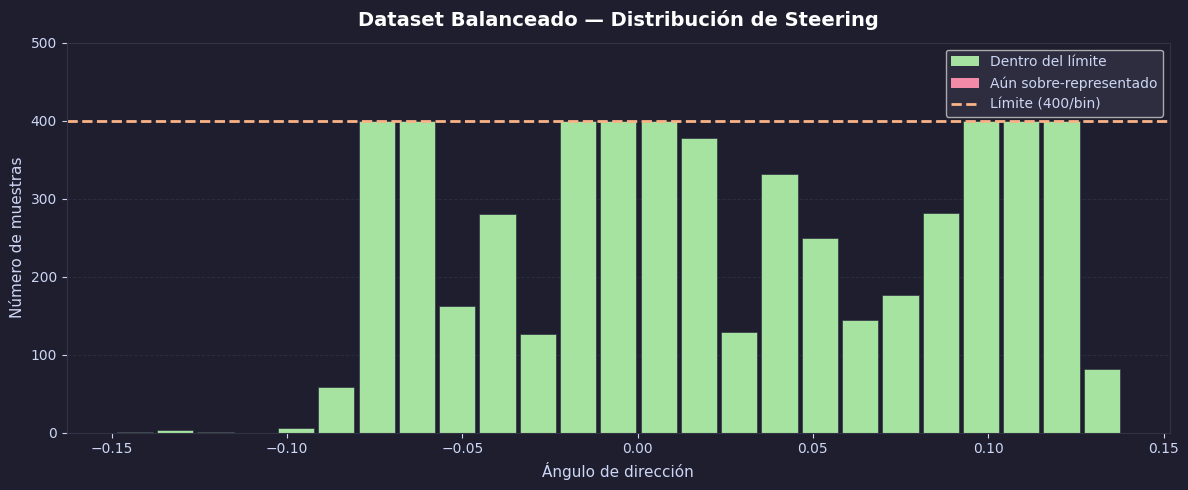

In [ ]:
print(f"Total antes del balanceo : {len(data):,}")

remove_list = []
for j in range(num_bins):
    mask = (data['steering'] >= bins[j]) & (data['steering'] <= bins[j + 1])
    bin_indices = data.index[mask].tolist()
    bin_indices = shuffle(bin_indices)
    remove_list.extend(bin_indices[samples_per_bin:])

data.drop(index=remove_list, inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"Registros eliminados     : {len(remove_list):,}")
print(f"Registros restantes      : {len(data):,}")

# --- Histograma post-balanceo ---
hist_bal, _ = np.histogram(data['steering'], num_bins)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

colors_bal = ['#f38ba8' if h > samples_per_bin else '#a6e3a1' for h in hist_bal]
ax.bar(center, hist_bal, width=width * 0.9, color=colors_bal, edgecolor='#313244', linewidth=0.5)
ax.axhline(samples_per_bin, color='#fab387', linewidth=2, linestyle='--')
ax.set_ylim(0, max(hist_bal) * 1.25)

ax.set_title('Dataset Balanceado — Distribución de Steering', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ángulo de dirección', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Número de muestras', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

leyenda = [
    Patch(facecolor='#a6e3a1', label='Dentro del límite'),
    Patch(facecolor='#f38ba8', label='Aún sobre-representado'),
    plt.Line2D([0], [0], color='#fab387', linewidth=2, linestyle='--', label=f'Límite ({samples_per_bin}/bin)'),
]
ax.legend(handles=leyenda, facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def load_img_steering(df):
    image_paths = []
    steerings = []
    for i in range(len(df)):
        row = df.iloc[i]
        image_paths.append(row['image_path'].strip())
        steerings.append(float(row['steering']))
    return np.asarray(image_paths), np.asarray(steerings)

image_paths, steerings = load_img_steering(data)

print(f"Filas en dataset  : {len(data):,}")
print(f"Imagenes totales  : {len(image_paths):,}")
print(f"Ejemplo de ruta   : {image_paths[0]}")
print(f"Steering min/max  : {steerings.min():.3f} / {steerings.max():.3f}")

Filas en dataset  : 5,611
Imagenes totales  : 5,611
Ejemplo de ruta   : dataset/images/JC_20260621_135651_549496.png
Steering min/max  : -0.149 / 0.138


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(image_paths, steerings, test_size=0.2, random_state=6)
print('Training Samples: {}\nValid Samples: {}'.format(len(X_train), len(X_valid)))

Training Samples: 4488
Valid Samples: 1123


## **<font color="orange">Distribución: Entrenamiento vs Validación</font>**

Tras dividir el dataset con `train_test_split` (80 % entrenamiento / 20 %
validación), graficamos el histograma de `steering` de cada subconjunto por
separado.

El objetivo es **verificar que la división fue representativa**: ambas
distribuciones deben tener una forma muy parecida. Si el conjunto de validación
tuviera una distribución distinta a la de entrenamiento (p. ej. sin curvas), la
métrica `val_loss` no reflejaría de forma fiable el desempeño real del modelo.

Como `train_test_split` baraja los datos antes de partirlos, esperamos que las
dos gráficas sean coherentes entre sí (apenas con una diferencia de escala por
el menor número de muestras de validación).

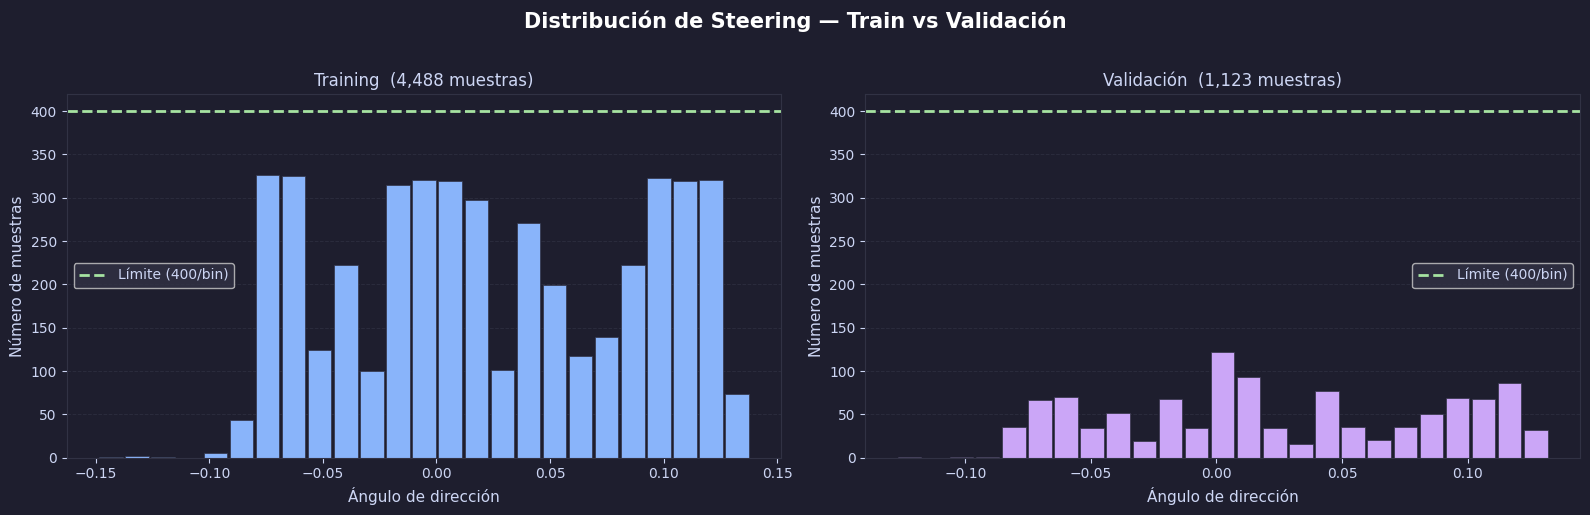

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Distribución de Steering — Train vs Validación', color='white', fontsize=15, fontweight='bold', y=1.02)

datasets = [
    (axes[0], y_train, '#89b4fa', f'Training  ({len(y_train):,} muestras)'),
    (axes[1], y_valid, '#cba6f7', f'Validación  ({len(y_valid):,} muestras)'),
]

for ax, y, color, titulo in datasets:
    hist, bin_edges = np.histogram(y, bins=num_bins)
    centers = (bin_edges[:-1] + bin_edges[1:]) * 0.5
    w = bin_edges[1] - bin_edges[0]
    ax.set_facecolor('#1e1e2e')
    ax.bar(centers, hist, width=w * 0.9, color=color, edgecolor='#313244', linewidth=0.5)
    ax.axhline(samples_per_bin, color='#a6e3a1', linewidth=2, linestyle='--', label=f'Límite ({samples_per_bin}/bin)')
    ax.set_title(titulo, color='#cdd6f4', fontsize=12)
    ax.set_xlabel('Ángulo de dirección', color='#cdd6f4', fontsize=11)
    ax.set_ylabel('Número de muestras', color='#cdd6f4', fontsize=11)
    ax.tick_params(colors='#cdd6f4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')
    ax.grid(axis='y', color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

## **<font color="orange">Augmentación de Imágenes</font>**

Cada muestra es una imagen RGB de la cámara frontal (`76×320×3`) junto con su
ángulo de dirección. Aun con el dataset balanceado, **5,611 imágenes son pocas**
para que la red generalice bien: tiende a memorizar el circuito en vez de
aprender a conducir.

La **augmentación de datos** ataca este problema generando, sobre la marcha,
variantes ligeramente modificadas de cada imagen. Así el modelo ve en la
práctica un conjunto mucho mayor y más diverso, se vuelve robusto a cambios de
iluminación y encuadre, y **reduce el sobreajuste**.

En las siguientes celdas definimos y visualizamos cada operación por separado:

| Operación | Función | Efecto | ¿Afecta al `steering`? |
|---|---|---|---|
| **Zoom** | `zoom` | Acerca la imagen hasta ×1.3 | No |
| **Pan** (desplazamiento) | `pan` | Traslada la imagen ±10 % en X e Y | No |
| **Brillo** | `img_random_brightness` | Multiplica el brillo (×0.2 a ×1.2) | No |
| **Flip** (volteo horizontal) | `img_random_flip` | Refleja la imagen como en un espejo | **Sí**: invierte el signo del ángulo |

> El **flip** es el único que modifica la etiqueta: al reflejar la escena, una
> curva a la derecha se convierte en una a la izquierda, por lo que el ángulo
> debe cambiar de signo (`steering → -steering`).

Finalmente, `random_augment` combina las cuatro operaciones aplicando cada una
**de forma aleatoria (probabilidad 0.5)**. Esta función se usará únicamente
durante el entrenamiento; las imágenes de validación se dejan sin alterar.

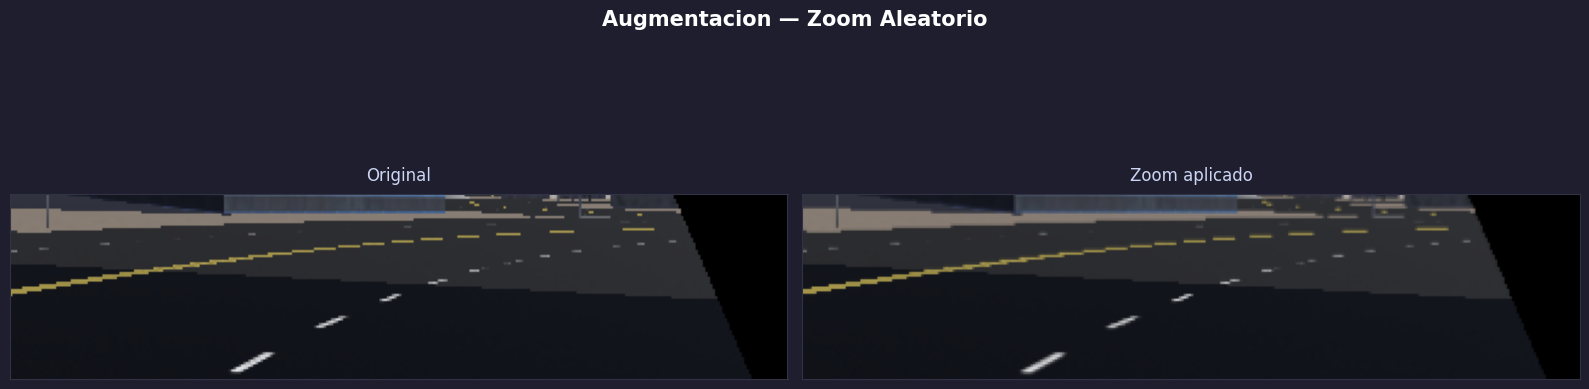

In [ ]:
def zoom(image):
    zoom = iaa.Affine(scale=(1, 1.3))
    image = zoom.augment_image(image)
    return image

image = image_paths[random.randint(0, len(image_paths) - 1)]
original_image = load_image(image)
zoomed_image = zoom(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Zoom Aleatorio', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image, 'Original'),
    (axes[1], zoomed_image,   'Zoom aplicado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

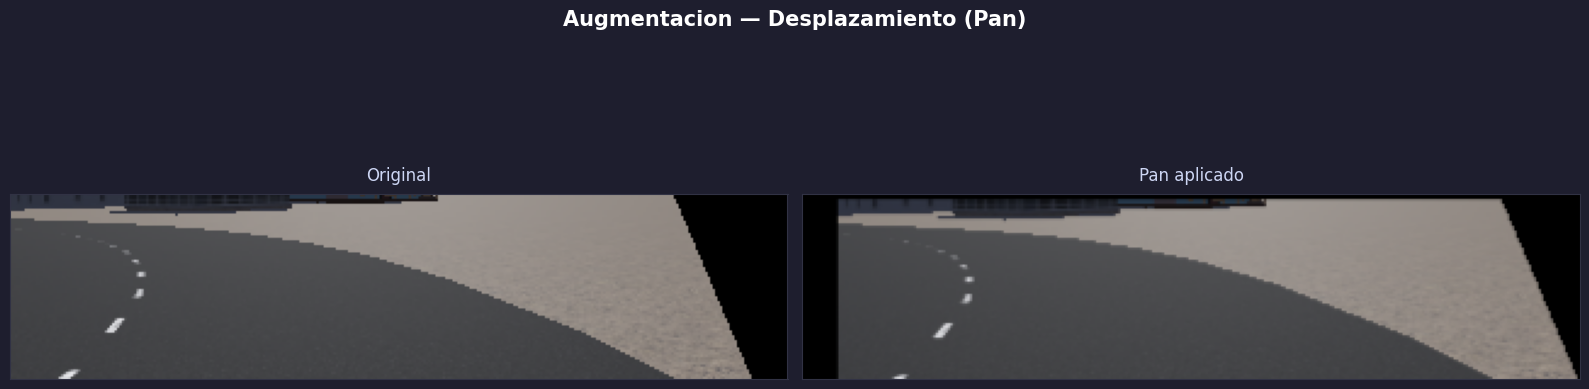

In [ ]:
def pan(image):
    pan = iaa.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)})
    image = pan.augment_image(image)
    return image

image = image_paths[random.randint(0, len(image_paths) - 1)]
original_image = load_image(image)
panned_image = pan(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Desplazamiento (Pan)', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image, 'Original'),
    (axes[1], panned_image,   'Pan aplicado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

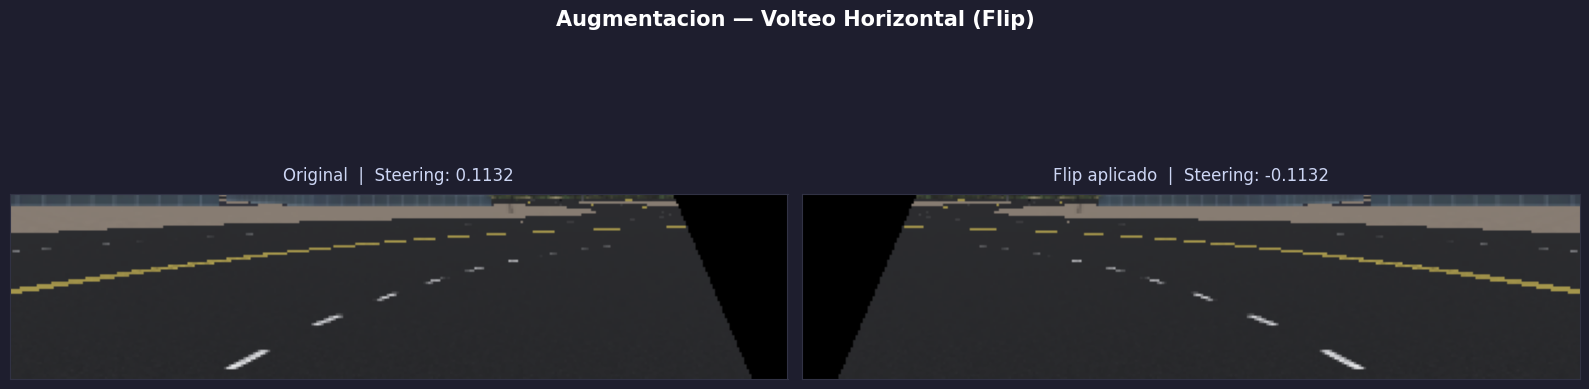

In [ ]:
def img_random_flip(image, steering_angle):
    image = cv2.flip(image, 1)
    steering_angle = -steering_angle
    return image, steering_angle

random_index = random.randint(0, len(image_paths) - 1)
original_image = load_image(image_paths[random_index])
steering_angle = steerings[random_index]
flipped_image, flipped_steering = img_random_flip(original_image, steering_angle)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Volteo Horizontal (Flip)', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo, angle in [
    (axes[0], original_image, 'Original',        steering_angle),
    (axes[1], flipped_image,  'Flip aplicado',   flipped_steering),
]:
    ax.imshow(img)
    ax.set_title(f'{titulo}  |  Steering: {angle:.4f}', color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

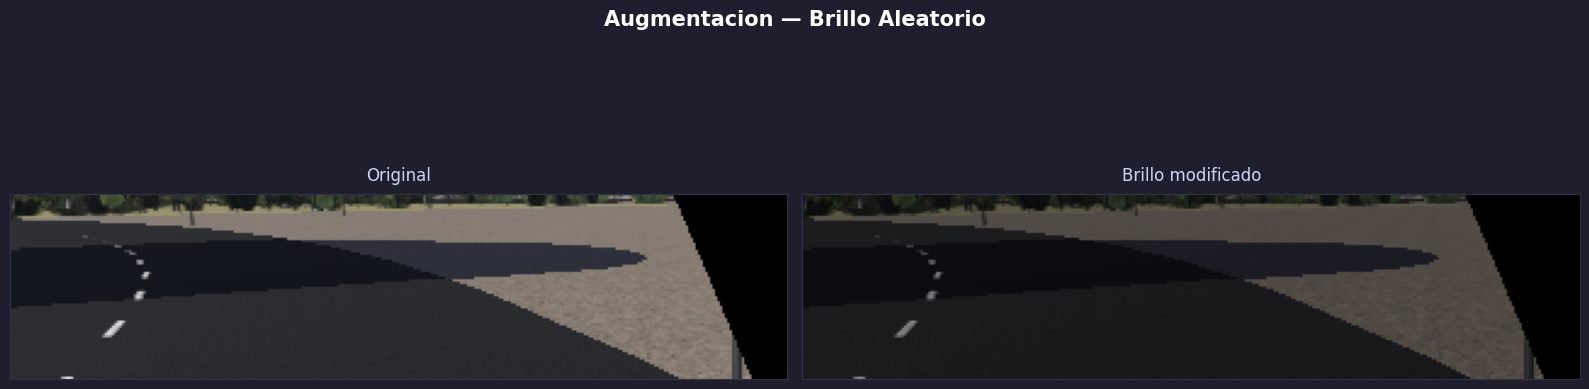

In [ ]:
def img_random_brightness(image):
    brightness = iaa.Multiply((0.2, 1.2))
    image = brightness.augment_image(image)
    return image

original_image = load_image(image_paths[random.randint(0, len(image_paths) - 1)])
brightness_altered_image = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion — Brillo Aleatorio', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, titulo in [
    (axes[0], original_image,         'Original'),
    (axes[1], brightness_altered_image, 'Brillo modificado'),
]:
    ax.imshow(img)
    ax.set_title(titulo, color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

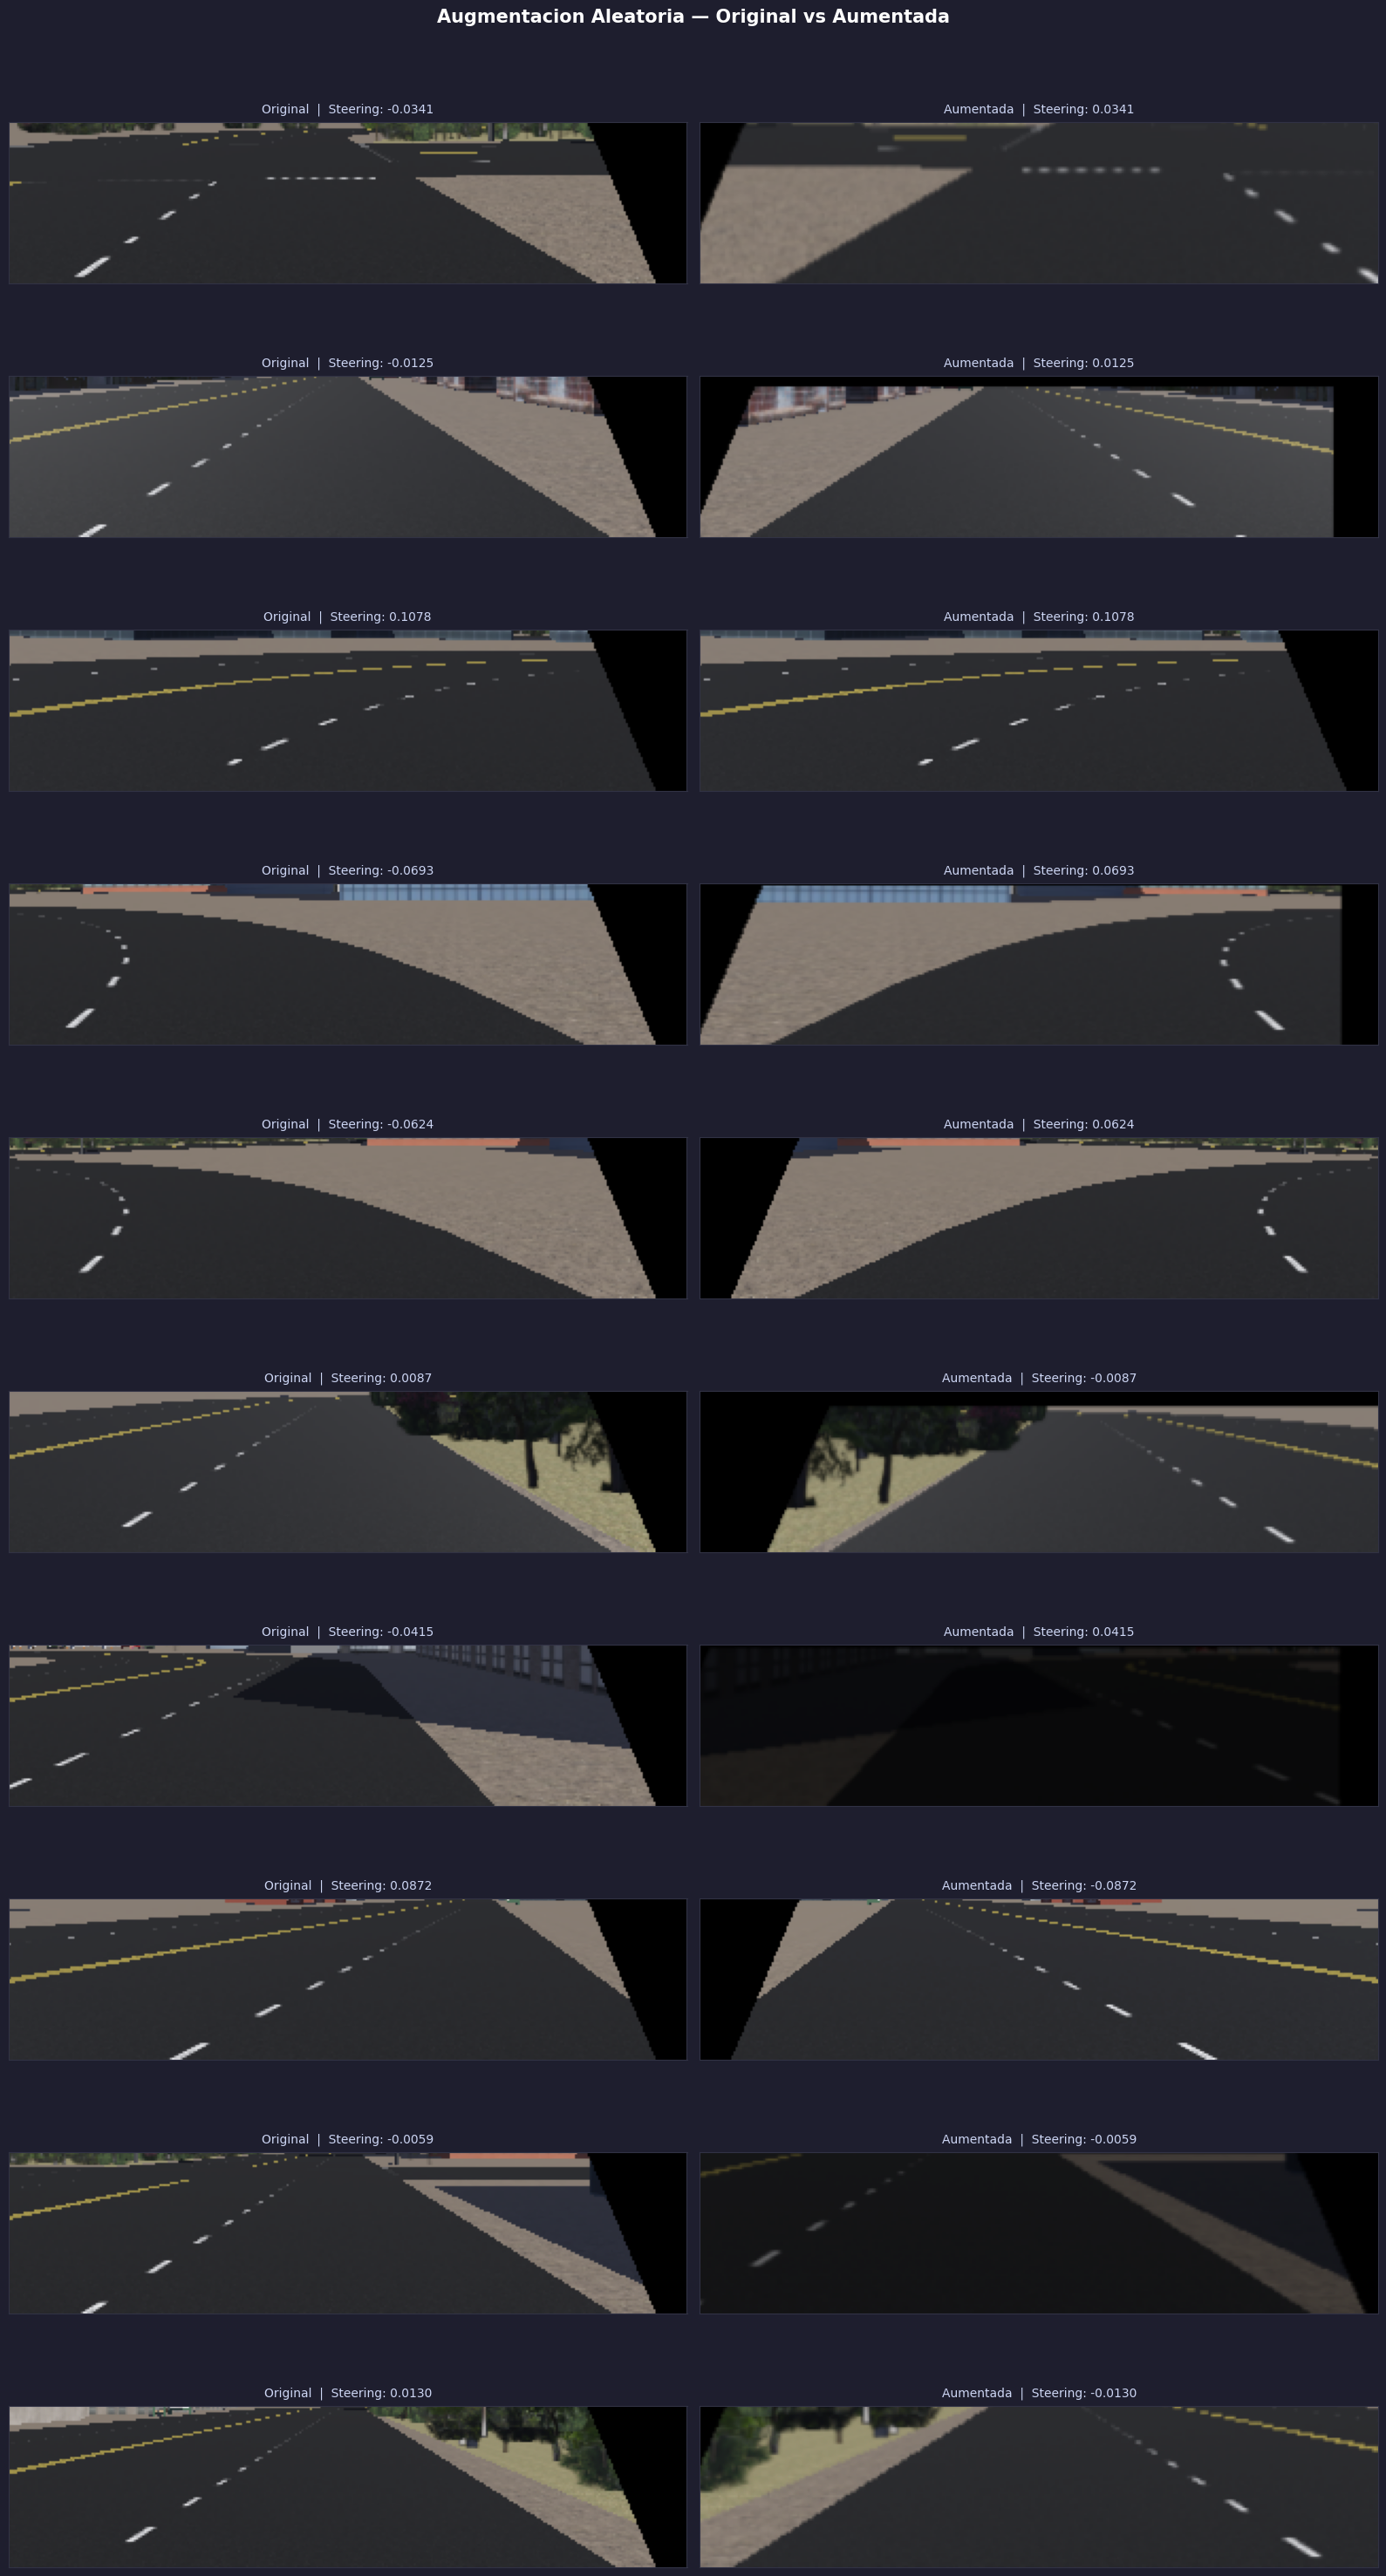

In [ ]:
def random_augment(image, steering_angle):
    image = load_image(image)
    if np.random.rand() < 0.5:
        image = pan(image)
    if np.random.rand() < 0.5:
        image = zoom(image)
    if np.random.rand() < 0.5:
        image = img_random_brightness(image)
    if np.random.rand() < 0.5:
        image, steering_angle = img_random_flip(image, steering_angle)
    return image, steering_angle

nrow = 10
fig, axes = plt.subplots(nrow, 2, figsize=(16, nrow * 3))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Augmentacion Aleatoria — Original vs Aumentada', color='white', fontsize=15, fontweight='bold', y=1.005)

for i in range(nrow):
    idx = random.randint(0, len(image_paths) - 1)
    original_image  = load_image(image_paths[idx])
    augmented_image, steering = random_augment(image_paths[idx], steerings[idx])

    for ax, img, titulo in [
        (axes[i][0], original_image,  f'Original  |  Steering: {steerings[idx]:.4f}'),
        (axes[i][1], augmented_image, f'Aumentada  |  Steering: {steering:.4f}'),
    ]:
        ax.imshow(img)
        ax.set_title(titulo, color='#cdd6f4', fontsize=10, pad=8)
        ax.set_facecolor('#1e1e2e')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

In [ ]:
def img_preprocess(img):
    img = img / 255
    return img

In [ ]:
def batch_generator(image_paths, steering_ang, batch_size, istraining):
    while True:
        batch_img      = []
        batch_steering = []

        for i in range(batch_size):
            random_index = random.randint(0, len(image_paths) - 1)

            if istraining:
                im, steering = random_augment(image_paths[random_index], steering_ang[random_index])
            else:
                im       = load_image(image_paths[random_index])
                steering = steering_ang[random_index]

            batch_img.append(img_preprocess(im))
            batch_steering.append(steering)

        yield np.asarray(batch_img), np.asarray(batch_steering)

print("batch_generator definido correctamente.")
print(f"  Entrenamiento : {len(X_train):,} imagenes")
print(f"  Validacion    : {len(X_valid):,} imagenes")

batch_generator definido correctamente.
  Entrenamiento : 4,488 imagenes
  Validacion    : 1,123 imagenes


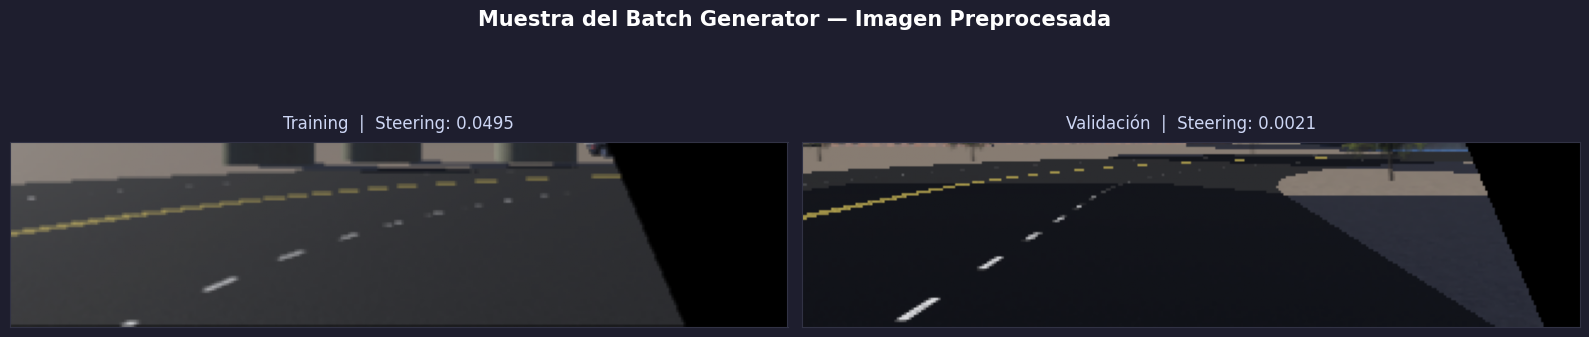

In [ ]:
x_train_gen, y_train_gen = next(batch_generator(X_train, y_train, 1, 1))
x_valid_gen, y_valid_gen = next(batch_generator(X_valid, y_valid, 1, 0))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('Muestra del Batch Generator — Imagen Preprocesada', color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, img, steering, titulo in [
    (axes[0], x_train_gen[0], y_train_gen[0], 'Training'),
    (axes[1], x_valid_gen[0], y_valid_gen[0], 'Validación'),
]:
    ax.imshow(img)
    ax.set_title(f'{titulo}  |  Steering: {steering:.4f}', color='#cdd6f4', fontsize=12, pad=10)
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

## **<font color="orange">Arquitectura de la Red (NVIDIA CNN)</font>**

Usamos la red convolucional del artículo de NVIDIA
[*End to End Learning for Self-Driving Cars*](https://arxiv.org/abs/1604.07316)
(Bojarski et al., 2016). Es un modelo de **regresión**: recibe una imagen
`76×320×3` y produce **un único número**, el ángulo de dirección.

La red se organiza en dos bloques con funciones distintas:

### **<font color=" #06bbd8">1. Bloque convolucional — *extracción de características*</font>**

Cinco capas `Conv2D` que aprenden, de lo simple a lo complejo, los rasgos
visuales relevantes para conducir (bordes → líneas del carril → geometría de la
curva):

| Capa | Filtros | Kernel | Stride | Salida (H×W×C) |
|---|---|---|---|---|
| Conv2D 1 | 24 | 5×5 | 2 | 36×158×24 |
| Conv2D 2 | 36 | 5×5 | 2 | 16×77×36 |
| Conv2D 3 | 48 | 5×5 | 2 | 6×37×48 |
| Conv2D 4 | 64 | 3×3 | 1 | 4×35×64 |
| Conv2D 5 | 64 | 3×3 | 1 | 2×33×64 |

El **stride 2** de las primeras tres capas reduce la resolución
progresivamente; por eso este diseño **no usa capas de *pooling***. La salida se
aplana (`Flatten`) en un vector de **4 224** valores.

### **<font color=" #06bbd8">2. Bloque denso — *regresión del ángulo*</font>**

Capas totalmente conectadas que traducen las características en el valor de
`steering`:

`Dense(100) → Dropout(0.5) → Dense(50) → Dropout(0.5) → Dense(10) → Dense(1)`

- Los dos **`Dropout(0.5)`** apagan la mitad de las neuronas en cada paso de
  entrenamiento, lo que **combate el sobreajuste**.
- La capa final `Dense(1)` **no lleva activación** (salida lineal), porque el
  ángulo es un valor continuo que puede ser positivo o negativo.

### **<font color=" #06bbd8">3. Detalles de diseño y compilación</font>**

- **Activación ELU** en todas las capas ocultas (en lugar de ReLU): produce
  gradientes suaves y evita el problema de las "neuronas muertas", lo que ayuda
  en tareas de regresión.
- **Pérdida `mse`** (error cuadrático medio): penaliza fuerte las desviaciones
  grandes del ángulo predicho.
- **Optimizador Adam** con tasa de aprendizaje baja (`1e-4`) para un ajuste
  estable y fino.
- **≈ 559 K parámetros** entrenables (~2.1 MB), un modelo ligero apto para
  ejecutarse en tiempo real.

In [ ]:
def nvidia_model():
    model = Sequential([
        Input(shape=(76, 320, 3)),

        # Bloque convolucional — extracción de características
        Conv2D(24, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(36, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(48, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),

        Flatten(),

        # Bloque denso — regresión del ángulo de dirección
        Dense(100, activation='elu'),
        Dropout(0.5),
        Dense(50,  activation='elu'),
        Dropout(0.5),
        Dense(10,  activation='elu'),
        Dense(1),
    ])

    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
    return model

model = nvidia_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 36, 158, 24)    │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 77, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 37, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 35, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 33, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4224)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       422,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,419 (2.13 MB)

 Trainable params: 559,419 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


callbacks = [
    ModelCheckpoint(
        'nvidia_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

val_steps = math.ceil(len(X_valid) / 100)

history = model.fit(
    batch_generator(X_train, y_train, 100, 1),
    steps_per_epoch  = 300,
    epochs           = 50,
    validation_data  = batch_generator(X_valid, y_valid, 100, 0),
    validation_steps = val_steps,
    callbacks        = callbacks,
    verbose          = 1,
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - loss: 0.0189
Epoch 1: val_loss improved from None to 0.00115, saving model to nvidia_model.keras

Epoch 1: finished saving model to nvidia_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 148s 491ms/step - loss: 0.0094 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - loss: 0.0047
Epoch 2: val_loss improved from 0.00115 to 0.00099, saving model to nvidia_model.keras

Epoch 2: finished saving model to nvidia_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 179s 599ms/step - loss: 0.0043 - val_loss: 9.9154e-04 - learning_rate: 1.0000e-04
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - loss: 0.0035
Epoch 3: val_loss did not improve from 0.00099
300/300 ━━━━━━━━━━━━━━━━━━━━ 166s 552ms/step - loss: 0.0033 - val_loss: 0.0010 - learning_rate: 1.0000e-04
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - loss: 0.0029
Epoch 4: val_loss improved from 0.00099 to 0.00082, saving model to nvidi

## **<font color="orange">Curva de Pérdida del Entrenamiento</font>**

Esta gráfica traza la pérdida **MSE** época a época para los dos conjuntos:

- **Entrenamiento** (`loss`, azul): error sobre los lotes aumentados.
- **Validación** (`val_loss`, rosa): error sobre imágenes reales sin alterar.
- La línea vertical marca la **mejor época** (menor `val_loss`), que es el peso
  que `ModelCheckpoint`/`EarlyStopping` conservan.

### Cómo se interpreta
- Si **ambas curvas bajan** y se mantienen juntas → el modelo aprende y
  generaliza bien.
- Si `loss` sigue bajando pero `val_loss` se estanca o sube → **sobreajuste**.
- Una `val_loss` que se aplana indica que ya no hay mucho más que aprender; ahí
  entra `ReduceLROnPlateau` bajando la tasa de aprendizaje para afinar.

### Observaciones de esta corrida
- La pérdida cae muy rápido en las primeras épocas y luego se aplana: el modelo
  alcanza una **`val_loss` ≈ 4.3 × 10⁻⁴** (RMSE ≈ 0.021) hacia el final.
- `val_loss` queda **por debajo** de `loss` durante casi todo el entrenamiento.
  Esto **no es un error**: en entrenamiento se aplican augmentación y `Dropout`
  (condiciones más difíciles), mientras que la validación usa imágenes limpias.
- `ReduceLROnPlateau` fue reduciendo la tasa de `1e-4` hasta `1e-6`, lo que
  permitió pequeñas mejoras finales sin que `EarlyStopping` llegara a detener.


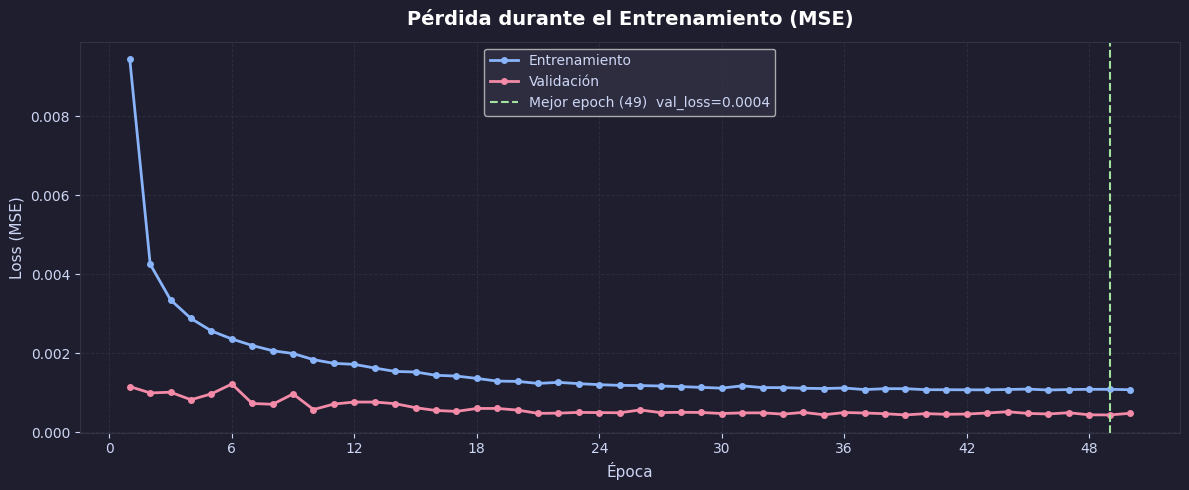

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

epochs = range(1, len(history.history['loss']) + 1)

ax.plot(epochs, history.history['loss'],     color='#89b4fa', linewidth=2, marker='o', markersize=4, label='Entrenamiento')
ax.plot(epochs, history.history['val_loss'], color='#f38ba8', linewidth=2, marker='o', markersize=4, label='Validación')

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_val   = min(history.history['val_loss'])
ax.axvline(best_epoch, color='#a6e3a1', linewidth=1.5, linestyle='--', label=f'Mejor epoch ({best_epoch})  val_loss={best_val:.4f}')

ax.set_title('Pérdida durante el Entrenamiento (MSE)', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Época', color='#cdd6f4', fontsize=11)
ax.set_ylabel('Loss (MSE)', color='#cdd6f4', fontsize=11)
ax.tick_params(colors='#cdd6f4')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.grid(color='#313244', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
model_path = 'nvidia_model.keras'
model.save(model_path)
print(f"Modelo guardado en '{model_path}'")
print(f"Tamaño : {os.path.getsize(model_path) / 1e6:.2f} MB")

Modelo guardado en 'nvidia_model.keras'
Tamaño : 6.78 MB


# **<font color="orange">Referencias</font>**

* Bojarski, M., Del Testa, D., Dworakowski, D., Firner, B., Flepp, B., Go
yal, P., Jackel, L. D., Monfort, M., Muller, U., Zhang, J., Zhang, X., Zhao,
J., & Zieba, K. (2016). End-to-End Learning for Self-Driving Cars. arXiv.
https://doi.org/10.48550/arXiv.1604.07316

*  Codevilla, F., Müller, M., López, A. M., Koltun, V., & Dosovitskiy, A. (2018).
End-to-End Driving via Conditional Imitation Learning. Proceedings of the
IEEE International Conference on Robotics and Automation (ICRA).
https://doi.org/10.1109/ICRA.2018.8460487

* Venturi, L., & Korda, K. (2020). Hands-on vision and behavior for self-driving cars. Packt Publishing. https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtml.

Declaración de uso de inteligencia artificial Anthropic. (2026). Claude (claude-sonnet-4-6) [Modelo de lenguaje grande], utilizado para refinamiento de código de python https://claude.ai

<center>

**Equipo 01 • Tecnológico de Monterrey • 2026**

</center>